In [180]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import os
import re
import sys
import matplotlib.pyplot as plt
import random
import pickle
from Functions.TedaGraphs import *
from Functions.Graphs import *
from scipy.interpolate import interp1d

def get_interpolation_func(x_array, y_array, kind='slinear'):
    f = interp1d(x_array, y_array, kind=kind, fill_value="extrapolate")
    return f


In [183]:
File = 'CY25-05_1-#1.csv'
path = f'Dataset/Dataset_1_NCA_battery/Dataset_1_NCA_battery/{File}'
out = f'Dataset/Dataset_1_NCA_battery_R01/{File[:-4]}'
os.makedirs(out,exist_ok=True)

df = pd.read_csv(path)
T = df.iloc[:,0].values
v= df.iloc[:,2].values
I = df.iloc[:,3].values
tvec = np.array([])
iref = np.array([])
for j,t in enumerate(T):
    if j >0:
        if I[j-1]==0 and I[j]>I[j-1]:
            tvec = np.append(tvec,t)
            iref = np.append(iref,j)
#V = (V-np.min(V))/(np.max(V)-np.min(V))
#I = (I-np.min(I))/(np.max(I)-np.min(I))
#plt.plot(T[:1400],I[:1400])
#plt.plot([tvec[0],tvec[0]],[0,1])
#plt.plot([tvec[1],tvec[1]],[0,1])
x = [T[:1400],[tvec[0],tvec[0]],[tvec[1],tvec[1]]]
y = [I[:1400],[np.min(I),np.max(I)],[np.min(I),np.max(I)]]
series = [x,y]
#i = (i-np.min(i))/(np.max(i)-np.min(i))
#plot_2series(x1=t,x2=t,y1=v,y2=i,w=800)
plot_series(series,show=False)

for i in range(len(iref)):
    if i == 0: 
        df2 = df[0:int(iref[i])]
    else:
        df2 = df[int(iref[i-1]):int(iref[i])]
    out_file = os.path.join(out,f'{i+1}.csv')
    df2.to_csv(out_file,index=False)

In [146]:
path = r'Dataset\Dataset_1_NCA_battery_R01\CY25-05_1-#1\4.csv'
df = pd.read_csv(path)
#df = normalize_df(df)
t2 = df.iloc[:,0].values
v2 = df.iloc[:,2].values
i2 = df.iloc[:,3].values
dQ2 = df.iloc[:,4].values
cQ2 = df.iloc[:,5].values
vds2 = v2[(i2<0)]
ids2 = i2[(i2<0)]
qds2 = dQ2[(i2<0)]
tds2 = t2[(i2<0)]



11.600783625394797


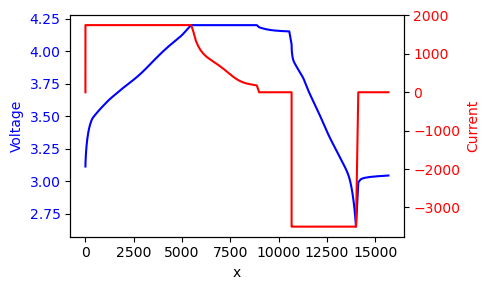

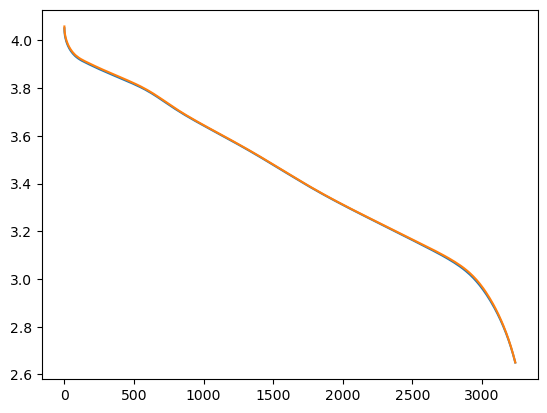

In [189]:
path = r'Dataset\Dataset_1_NCA_battery_R01\CY25-05_1-#1\1.csv'
df = pd.read_csv(path)
#df = normalize_df(df)
t = df.iloc[:,0].values
v = df.iloc[:,2].values
i = df.iloc[:,3].values
dQ = df.iloc[:,4].values
cQ = df.iloc[:,5].values

vds = v[(i<0)]
ids = i[(i<0)]
qds = dQ[(i<0)]
tds = t[(i<0)]

print(np.max(cQ)-np.max(dQ))
PlotTwoScales(t,t,v,i,y1_name='Voltage',y2_name='Current')
#PlotTwoScales(t,t,cQ,dQ,y1_name='Charging',y2_name='Discharging')
#PlotTwoScales(t,tds,v,vds,y1_name='Current',y2_name='Discharging')
#plt.plot(dQ,v)
#plt.plot(dQ2,v2)
#plot_single(x=qds2,y=vds2)
#plot_single(x=T,y=V)
#plt.plot(qds,vds)
#plt.plot(qds2,vds2)
#plt.plot(t2,vds)
#plt.plot(t2,ids)
plt.plot(qds,vds)
plt.plot(qds2,vds2)


In [250]:
path = r'Dataset\Dataset_1_NCA_battery_R01\CY25-05_1-#1\5.csv'
df = pd.read_csv(path)
i = df.iloc[:,3].values
v = df.iloc[:,2].values
dQ = df.iloc[:,4].values
vds1 = v[(i<0)]
qds1 = dQ[(i<0)]
fQV_5 = get_interpolation_func(vds1, qds1, kind='nearest')

path = r'Dataset\Dataset_1_NCA_battery_R01\CY25-05_1-#1\20.csv'
df = pd.read_csv(path)
i = df.iloc[:,3].values
v = df.iloc[:,2].values
dQ = df.iloc[:,4].values
vds2 = v[(i<0)]
qds2 = dQ[(i<0)]
fQV_30 = get_interpolation_func(vds2, qds2, kind='nearest')

print(vds1[-1],vds2[-1])
print(qds1[-1],qds2[-1])
print(fQV_30(2.65),fQV_5(2.65))
print(fQV_30(2.65)-fQV_5(2.65))
print(qds1[-1]-qds2[-1])

2.6499565 2.6498778
3239.497770822481 3190.40914548462
3190.40914548462 3239.497770822481
-49.08862533786123
49.08862533786123


In [256]:
dir = r'Dataset\Dataset_1_NCA_battery_R01\CY25-05_1-#1'
samples = os.listdir(dir)
samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
CT,CCCT,CVCT,Qmax,DQV,SDC = [np.array([]) for i in range(6)]
df2 = pd.DataFrame()
vDQ = []
vV = []
for sample in samples[:-1]:
    path = os.path.join(dir,sample)
    df = pd.read_csv(path)
    t = df.iloc[:,0].values
    v = df.iloc[:,2].values
    i = df.iloc[:,3].values
    dQ = df.iloc[:,4].values
    cQ = df.iloc[:,5].values

    vds = v[(i<0)]
    ids = i[(i<0)]
    qds = dQ[(i<0)]
    tds = t[(i<0)]

    vDQ.append(fQV_30(vds)-fQV_5(vds))
    vV.append(vds)
    #vec.append(np.flip(qds))
    ct = t[(cQ>0)]
    cvct = t[(v>=4.198) & (v<=4.21)]
    ccct = t[(i>=1740) & (v<=1751)]
    cvct_ = v[(v>=4.198) & (v<=4.21)]
    ccct_ = i[(i>=1740) & (i<=1751)]
    scd = np.gradient(dQ[(dQ>0) & (dQ<np.max(dQ))])
    #dqv = fQV_30()

    CT = np.append(CT,ct[-1]-ct[0])
    CCCT = np.append(CCCT,ccct[-1]-ccct[0])
    CVCT = np.append(CVCT,cvct[-1]-cvct[0])
    Qmax = np.append(Qmax,np.max(dQ))
    SDC = np.append(SDC,np.max(dQ))
df2['CT'] = CT
df2['CCCT'] = CCCT
df2['CVCT'] = CVCT
df2['Qmax'] = Qmax
df2['SDC'] = SDC


In [ ]:
plot_features(df2,cols_qtd=3,h=4,brng=' ')

IndexError: list index out of range

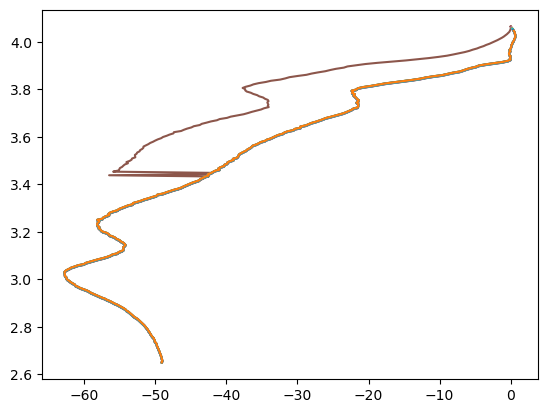

In [259]:
Is = [i*12 for i in range(14)]
for i in Is:
    plt.plot(vDQ[i],vV[i])


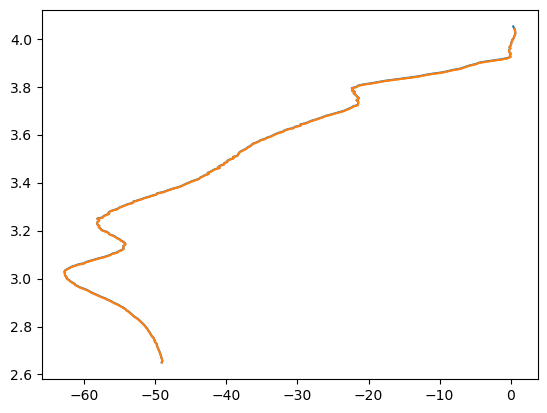

In [ ]:

plt.plot(vDQ[0],vV[0])
plt.plot(vDQ[-],vV[-1])